core           INFO 	Loading data for Spanish Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 19 drivers: ['81', '4', '16', '63', '27', '44', '6', '10', '14', '1', '30', '5', '22', '55', '43', '31', '87', '12', '23']


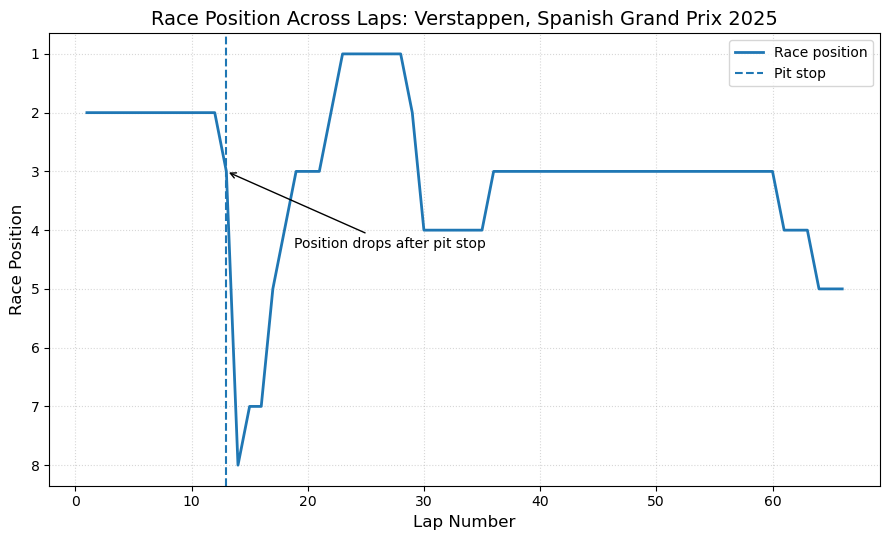

In [39]:
import os
import fastf1
import matplotlib.pyplot as plt
import pandas as pd

# Enable cache
fastf1.Cache.enable_cache("fastf1_cache")

# Load session
session = fastf1.get_session(2025, "Spain", "R")
session.load()

# Get Verstappen's race laps
laps = session.laps.pick_drivers("VER").sort_values("LapNumber").copy()

# Keep only laps with valid position data
laps = laps[pd.notna(laps["Position"])].copy()
laps["LapNumber"] = laps["LapNumber"].astype(int)
laps["Position"] = laps["Position"].astype(int)

# Identify pit stop lap(s)
pit_laps = laps.loc[pd.notna(laps["PitInTime"]), "LapNumber"].tolist()
first_pit_lap = pit_laps[0] if pit_laps else None

# Plot
plt.figure(figsize=(9, 5.5))

plt.plot(
    laps["LapNumber"],
    laps["Position"],
    linewidth=2,
    label="Race position"
)

# Highlight pit stop
if first_pit_lap is not None:
    plt.axvline(
        first_pit_lap,
        linestyle="--",
        linewidth=1.5,
        label="Pit stop"
    )

    post_stop = laps[laps["LapNumber"] >= first_pit_lap].head(3)
    if not post_stop.empty:
        ann_x = int(post_stop.iloc[0]["LapNumber"])
        ann_y = int(post_stop.iloc[0]["Position"])
        plt.annotate(
            "Position drops after pit stop",
            xy=(ann_x, ann_y),
            xytext=(ann_x + 5.8, ann_y + 1.3),
            arrowprops=dict(arrowstyle="->", lw=1),
            fontsize=10
        )

# Invert y-axis so P1 is at the top
plt.gca().invert_yaxis()

# Labels and title
plt.title("Race Position Across Laps: Verstappen, Spanish Grand Prix 2025", fontsize=14)
plt.xlabel("Lap Number", fontsize=12)
plt.ylabel("Race Position", fontsize=12)

# Improve readability
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()

# Create folder if it does not exist
os.makedirs("figures", exist_ok=True)

# Save high-quality figure
plt.savefig("figures/figure1_position_spain.png", dpi=300, bbox_inches="tight")

# Show
plt.show()


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '4', '16', '44', '1', '10', '31', '22', '87', '12', '23', '6', '7', '14', '30', '18', '5', '55', '27']
C:\Users\Josel\AppData\Local\Temp\ipykernel_10824\3340637297.py

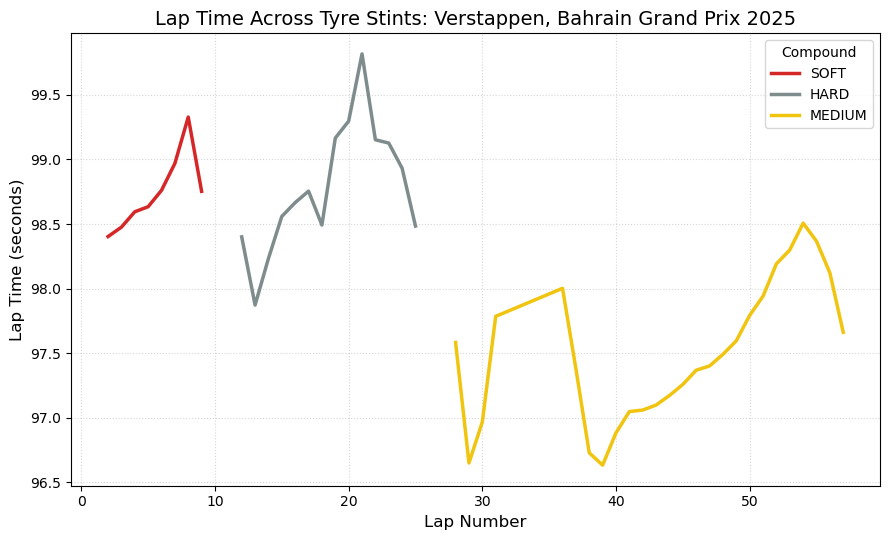

In [40]:
import os
import fastf1
import matplotlib.pyplot as plt
import pandas as pd

fastf1.Cache.enable_cache("fastf1_cache")

session = fastf1.get_session(2025, "Bahrain", "R")
session.load()

driver_code = "VER"
driver_name = "Verstappen"

laps = session.laps.pick_drivers(driver_code).copy()
laps = laps.sort_values("LapNumber")

# Keep valid laps only
laps = laps[
    pd.notna(laps["LapTime"]) &
    pd.notna(laps["Compound"]) &
    pd.notna(laps["LapNumber"])
].copy()

laps["LapTimeSeconds"] = laps["LapTime"].dt.total_seconds()
laps["LapNumber"] = laps["LapNumber"].astype(int)

# Remove pit in / pit out laps
if "PitInTime" in laps.columns:
    laps = laps[pd.isna(laps["PitInTime"])]
if "PitOutTime" in laps.columns:
    laps = laps[pd.isna(laps["PitOutTime"])]

# Keep only normal racing laps where possible
if "TrackStatus" in laps.columns:
    laps = laps[laps["TrackStatus"] == "1"]

# Remove laps that are much slower than the driver's normal pace
median_lap = laps["LapTimeSeconds"].median()
laps = laps[laps["LapTimeSeconds"] < median_lap + 3.0]

# Light smoothing after filtering
laps["LapTimeSmooth"] = laps["LapTimeSeconds"].rolling(window=3, center=True).mean()
laps["LapTimeSmooth"] = laps["LapTimeSmooth"].fillna(laps["LapTimeSeconds"])

compound_colours = {
    "SOFT": "#d62728",
    "MEDIUM": "#f1c40f",
    "HARD": "#7f8c8d"
}

plt.figure(figsize=(9, 5.5))

for compound in laps["Compound"].unique():
    comp_laps = laps[laps["Compound"] == compound]

    plt.plot(
        comp_laps["LapNumber"],
        comp_laps["LapTimeSmooth"],
        linewidth=2.5,
        label=compound,
        color=compound_colours.get(compound, None)
    )

plt.title(f"Lap Time Across Tyre Stints: {driver_name}, Bahrain Grand Prix 2025", fontsize=14)
plt.xlabel("Lap Number", fontsize=12)
plt.ylabel("Lap Time (seconds)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(title="Compound")
plt.tight_layout()

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/figure2_tyre_stints_bahrain.png", dpi=300, bbox_inches="tight")
plt.show()


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '4', '16', '44', '1', '10', '31', '22', '87', '12', '23', '6', '7', '14', '30', '18', '5', '55', '27']
C:\Users\Josel\AppData\Local\Temp\ipykernel_10824\1192101500.py

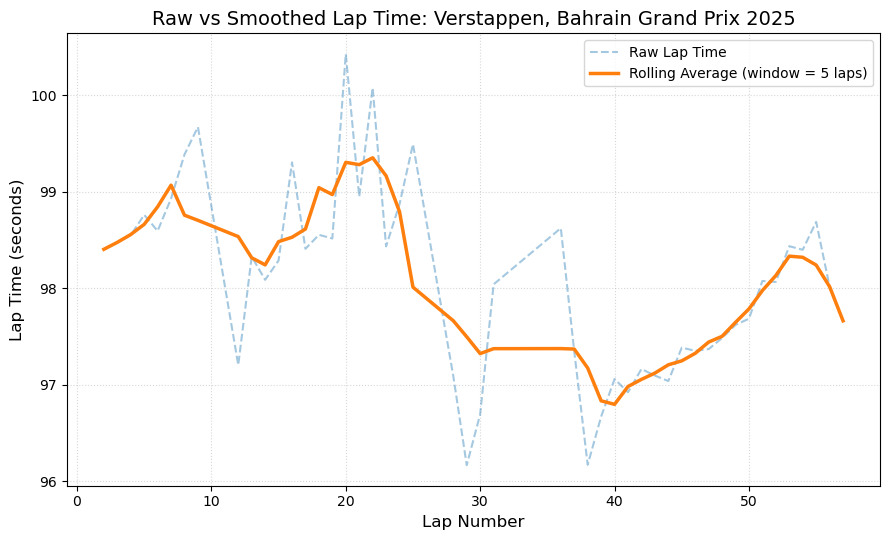

In [41]:
import os
import fastf1
import matplotlib.pyplot as plt
import pandas as pd

# Enable cache
fastf1.Cache.enable_cache("fastf1_cache")

# Load session
session = fastf1.get_session(2025, "Bahrain", "R")
session.load()

# Select driver
driver_code = "VER"
driver_name = "Verstappen"

laps = session.laps.pick_drivers(driver_code).copy()
laps = laps.sort_values("LapNumber")

# Keep valid laps
laps = laps[
    pd.notna(laps["LapTime"]) &
    pd.notna(laps["LapNumber"])
].copy()

# Convert to seconds
laps["LapTimeSeconds"] = laps["LapTime"].dt.total_seconds()

# ----------------------------
# CLEAN DATA (same logic as before)
# ----------------------------

# Remove pit laps
if "PitInTime" in laps.columns:
    laps = laps[pd.isna(laps["PitInTime"])]
if "PitOutTime" in laps.columns:
    laps = laps[pd.isna(laps["PitOutTime"])]

# Remove abnormal slow laps
median_lap = laps["LapTimeSeconds"].median()
laps = laps[laps["LapTimeSeconds"] < median_lap + 3.0]

# ----------------------------
# CREATE FEATURE (rolling average)
# ----------------------------

laps["RollingLapTime"] = laps["LapTimeSeconds"].rolling(window=5, center=True).mean()
laps["RollingLapTime"] = laps["RollingLapTime"].fillna(laps["LapTimeSeconds"])

# ----------------------------
# PLOT
# ----------------------------

plt.figure(figsize=(9, 5.5))

# Raw lap times (faded)
plt.plot(
    laps["LapNumber"],
    laps["LapTimeSeconds"],
    linewidth=1.5,
    linestyle="--",
    alpha=0.4,
    label="Raw Lap Time"
)

# Rolling average (main line)
plt.plot(
    laps["LapNumber"],
    laps["RollingLapTime"],
    linewidth=2.5,
    label="Rolling Average (window = 5 laps)"
)

plt.title(f"Raw vs Smoothed Lap Time: {driver_name}, Bahrain Grand Prix 2025", fontsize=14)
plt.xlabel("Lap Number", fontsize=12)
plt.ylabel("Lap Time (seconds)", fontsize=12)

plt.grid(True, linestyle=":", alpha=0.5)
plt.legend()
plt.tight_layout()

# Save
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/figure3_rolling_average.png", dpi=300, bbox_inches="tight")

plt.show()

In [42]:
df = laps[["LapNumber", "LapTime", "Compound", "TyreLife", "Position"]].copy()

# Convert LapTime to seconds
df["LapTime"] = df["LapTime"].dt.total_seconds()

# Rename column
df = df.rename(columns={"LapTime": "LapTime (s)"})

# Clean formatting
df["LapNumber"] = df["LapNumber"].astype(int)
df["TyreLife"] = df["TyreLife"].astype(int)
df["Position"] = df["Position"].astype(int)
df["LapTime (s)"] = df["LapTime (s)"].round(3)

# Reset index (removes 286, 287 etc.)
df = df.reset_index(drop=True)

df.head()

,LapNumber,LapTime (s),Compound,TyreLife,Position
0,2,98.403,SOFT,5,8
1,3,98.475,SOFT,6,8
2,4,98.549,SOFT,7,8
3,5,98.760,SOFT,8,7
4,6,98.593,SOFT,9,7


In [43]:
import pandas as pd

# ----------------------------
# RAW VERSION (as originally retrieved)
# ----------------------------
raw_df = laps[["LapNumber", "LapTime", "Compound", "TyreLife", "Position"]].head(5).copy()

# ----------------------------
# CLEANED VERSION
# ----------------------------
clean_df = raw_df.copy()

# Convert LapTime to seconds
clean_df["LapTime"] = clean_df["LapTime"].dt.total_seconds()

# Rename column
clean_df = clean_df.rename(columns={"LapTime": "LapTime (s)"})

# Clean formatting
clean_df["LapNumber"] = clean_df["LapNumber"].astype(int)
clean_df["TyreLife"] = clean_df["TyreLife"].astype(int)
clean_df["Position"] = clean_df["Position"].astype(int)
clean_df["LapTime (s)"] = clean_df["LapTime (s)"].round(3)

# Reset index
raw_df = raw_df.reset_index(drop=True)
clean_df = clean_df.reset_index(drop=True)

# ----------------------------
# DISPLAY SIDE BY SIDE
# ----------------------------
comparison = pd.concat(
    [raw_df, clean_df],
    axis=1,
    keys=["Raw Data", "Cleaned Data"]
)

comparison

Raw Data                                                   Cleaned Data  \
  LapNumber                LapTime Compound TyreLife Position    LapNumber   
0       2.0 0 days 00:01:38.403000     SOFT      5.0      8.0            2   
1       3.0 0 days 00:01:38.475000     SOFT      6.0      8.0            3   
2       4.0 0 days 00:01:38.549000     SOFT      7.0      8.0            4   
3       5.0 0 days 00:01:38.760000     SOFT      8.0      7.0            5   
4       6.0 0 days 00:01:38.593000     SOFT      9.0      7.0            6   

                                          
  LapTime (s) Compound TyreLife Position  
0      98.403     SOFT        5        8  
1      98.475     SOFT        6        8  
2      98.549     SOFT        7        8  
3      98.760     SOFT        8        7  
4      98.593     SOFT        9        7

C:\Users\Josel\AppData\Local\Temp\ipykernel_10824\883964365.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["LapTimeRolling"] = df["LapTimeSeconds"].rolling(window=3, center=True).mean()


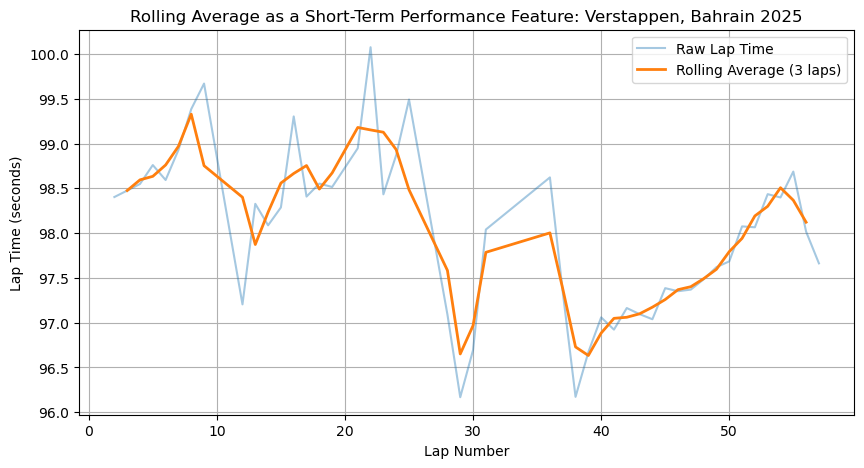

In [44]:
import matplotlib.pyplot as plt

# Copy data
df = laps.copy()

# Convert lap time to seconds
df["LapTimeSeconds"] = df["LapTime"].dt.total_seconds()

df = df[df["LapTimeSeconds"] < df["LapTimeSeconds"].quantile(0.99)]

# Rolling average (window = 3 laps)
df["LapTimeRolling"] = df["LapTimeSeconds"].rolling(window=3, center=True).mean()

# Plot
plt.figure(figsize=(10,5))

plt.plot(df["LapNumber"], df["LapTimeSeconds"], label="Raw Lap Time", alpha=0.4)
plt.plot(df["LapNumber"], df["LapTimeRolling"], label="Rolling Average (3 laps)", linewidth=2)

plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.title("Rolling Average as a Short-Term Performance Feature: Verstappen, Bahrain 2025")

plt.legend()
plt.grid()

plt.show()

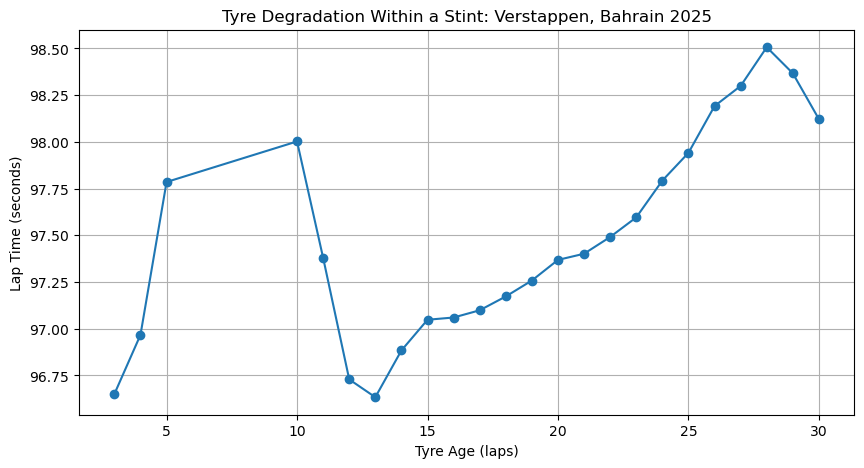

In [45]:
import matplotlib.pyplot as plt

# Start from cleaned df
stint = df[df["Compound"] == "MEDIUM"].copy()

# Identify separate stints (reset when TyreLife drops)
stint["StintGroup"] = (stint["TyreLife"].diff() < 0).cumsum()

# Keep ONLY first continuous stint
stint = stint[stint["StintGroup"] == stint["StintGroup"].iloc[0]]

# Smooth lap times
stint["LapTimeSmooth"] = stint["LapTimeSeconds"].rolling(window=3, center=True).mean()

# Plot
plt.figure(figsize=(10,5))

plt.plot(stint["TyreLife"], stint["LapTimeSmooth"], marker='o')

plt.xlabel("Tyre Age (laps)")
plt.ylabel("Lap Time (seconds)")
plt.title("Tyre Degradation Within a Stint: Verstappen, Bahrain 2025")

plt.grid()

plt.show()

In [46]:
feature_df = df[[
  "LapNumber",
  "LapTimeSeconds",
  "LapTimeRolling",
  "Compound",
  "TyreLife",
  "Position"
]].head(10)
feature_df = feature_df.dropna()
feature_df

,LapNumber,LapTimeSeconds,LapTimeRolling,Compound,TyreLife,Position
287,3.0,98.475,98.475667,SOFT,6.0,8.0
288,4.0,98.549,98.594667,SOFT,7.0,8.0
289,5.0,98.760,98.634000,SOFT,8.0,7.0
290,6.0,98.593,98.760667,SOFT,9.0,7.0
291,7.0,98.929,98.969000,SOFT,10.0,7.0
292,8.0,99.385,99.328000,SOFT,11.0,7.0
293,9.0,99.670,98.753000,SOFT,12.0,7.0
296,12.0,97.204,98.400333,HARD,2.0,16.0
297,13.0,98.327,97.872667,HARD,3.0,13.0


In [48]:
print(df.columns.tolist())

['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate', 'LapTimeSeconds', 'RollingLapTime', 'LapTimeRolling']


df_fe ready
    Driver  LapNumber  LapTimeSeconds  RollingLapTime  LapDelta Compound  \
286    VER        2.0          98.403         98.4030    0.0000     SOFT   
287    VER        3.0          98.475         98.4750    0.0000     SOFT   
288    VER        4.0          98.549         98.5560   -0.0070     SOFT   
289    VER        5.0          98.760         98.6612    0.0988     SOFT   
290    VER        6.0          98.593         98.8432   -0.2502     SOFT   

     TyreLife  TyreWearFrac  
286       5.0      0.277778  
287       6.0      0.333333  
288       7.0      0.388889  
289       8.0      0.444444  
290       9.0      0.500000  


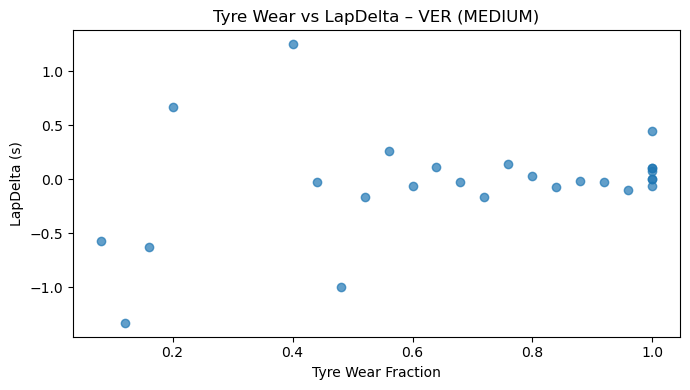

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

driver_col = "Driver"
lap_col = "LapNumber"
laptime_col = "LapTimeSeconds"
compound_col = "Compound"
tyrelife_col = "TyreLife"
team_col = "Team"
trackstatus_col = "TrackStatus"
position_col = "Position"
rolling_col = "RollingLapTime"

df_fe = df.copy()

# Sort by driver and lap
df_fe = df_fe.sort_values([driver_col, lap_col]).copy()

# Ensure rolling baseline exists
if rolling_col not in df_fe.columns:
    df_fe[rolling_col] = (
        df_fe.groupby(driver_col)[laptime_col]
        .transform(lambda s: s.rolling(3, min_periods=1).mean())
    )

# LapDelta target
df_fe["LapDelta"] = df_fe[laptime_col] - df_fe[rolling_col]

# TyreWearFrac
WEAR_CAP = {"SOFT": 18, "MEDIUM": 25, "HARD": 35}
cap = df_fe[compound_col].astype(str).str.upper().map(WEAR_CAP).fillna(25)
df_fe["TyreWearFrac"] = (pd.to_numeric(df_fe[tyrelife_col], errors="coerce") / cap).clip(0, 1)

print("df_fe ready")
print(df_fe[[driver_col, lap_col, laptime_col, rolling_col, "LapDelta", compound_col, tyrelife_col, "TyreWearFrac"]].head())



driver_value = df_fe[driver_col].mode().iloc[0]

sub = df_fe[df_fe[driver_col] == driver_value].copy()
sub = sub.sort_values(lap_col)

# Keep one compound for clarity
compound_value = sub[compound_col].mode().iloc[0]
sub = sub[sub[compound_col] == compound_value].copy()

plt.figure(figsize=(7,4))
plt.scatter(sub["TyreWearFrac"], sub["LapDelta"], alpha=0.7)

plt.xlabel("Tyre Wear Fraction")
plt.ylabel("LapDelta (s)")
plt.title(f"Tyre Wear vs LapDelta – {driver_value} ({compound_value})")

plt.tight_layout()
plt.show()

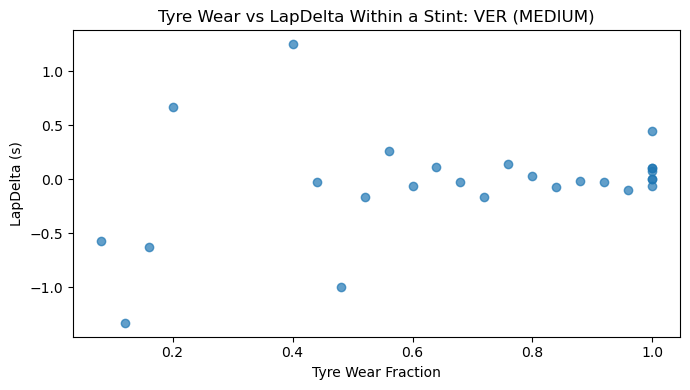

In [52]:
driver_value = df_fe[driver_col].mode().iloc[0]

sub = df_fe[df_fe[driver_col] == driver_value].copy()
sub = sub.sort_values(lap_col)

# Pick one compound
compound_value = sub[compound_col].mode().iloc[0]
sub = sub[sub[compound_col] == compound_value].copy()

# Split into continuous tyre-life runs
sub["StintGroup"] = (sub[tyrelife_col].diff() < 0).cumsum()

# Keep the largest continuous stint
largest_group = sub["StintGroup"].value_counts().idxmax()
st = sub[sub["StintGroup"] == largest_group].copy()

plt.figure(figsize=(7,4))
plt.scatter(st["TyreWearFrac"], st["LapDelta"], alpha=0.7)

plt.xlabel("Tyre Wear Fraction")
plt.ylabel("LapDelta (s)")
plt.title(f"Tyre Wear vs LapDelta Within a Stint: {driver_value} ({compound_value})")

plt.tight_layout()
plt.show()

In [57]:
from __future__ import annotations

from dataclasses import dataclass
from collections import deque
from typing import Iterable, List, Optional, Tuple, Dict
# ----------------------------
# Core simulator
# ----------------------------
WEAR_CAP_DEFAULT = {"SOFT": 18, "MEDIUM": 25, "HARD": 35}
def simulate_what_if_pit_stateful(
    df: pd.DataFrame,
    pace_model,
    race_id: str,
    driver_code: str,
    pit_lap: int,
    pit_loss_s: float = 22.0,
    horizon_laps: int = 25,
    pace_features: Optional[List[str]] = None,
    wear_cap: Dict[str, int] = WEAR_CAP_DEFAULT,
) -> pd.DataFrame:
    """
    Stateful 'what-if pit' simulator.

    Baseline:
      - Uses the real race rows as state templates
      - Predicts baseline lap time using pace_model at each lap

    What-if:
      - Forces a pit at pit_lap
      - Resets tyre age (TyreLife / LapsSinceLastPit) from pit_lap onward
      - Keeps the compound the same (configurable logic)
      - Adds a one-off pit loss to the pit lap
      - Updates rolling features (e.g., lap_avg_3) using predicted values,
        so later-lap predictions can change dynamically.

    Returns:
      DataFrame with LapNumber, predicted baseline lap time, predicted what-if lap time,
      per-lap delta, cumulative delta.
    """
    if pace_features is None:
        raise ValueError("Pass pace_features exactly as used to train pace_model (same order).")

    sub = get_driver_race_laps(df, race_id, driver_code)

    # Ensure required columns exist for feature computation
    require_features_exist(sub, [c for c in pace_features if c not in ("lap_avg_3", "TyreWearFrac")])

    max_lap = infer_total_laps(sub)
    end_lap = min(pit_lap + horizon_laps - 1, max_lap)
    if pit_lap > max_lap:
        raise ValueError(f"pit_lap={pit_lap} is beyond last lap={max_lap} for {driver_code} in {race_id}.")
    final_lap = max_lap

    comp_after = pick_same_compound(sub, pit_lap)

    # Seed rolling window with REAL LapTime_s values before pit lap if available
    # This helps lap_avg_3 behave sensibly at the first simulated laps.
    base_q = deque(maxlen=3)
    what_q = deque(maxlen=3)
    if "LapTime_s" in sub.columns:
        pre = sub[sub["LapNumber"].between(pit_lap - 3, pit_lap - 1)]
        seed = pre["LapTime_s"].dropna().tolist()
        base_q.extend(seed)
        what_q.extend(seed)

    rows = []

    for lap in range(pit_lap, end_lap + 1):
        row_real = sub.loc[sub["LapNumber"] == lap].iloc[0].copy()

        # -------------------------
        # Baseline row (real state template)
        # -------------------------
        base_row = row_real.copy()

        if "lap_avg_3" in base_row.index:
            base_row["lap_avg_3"] = _mean(base_q)

        if "TyreWearFrac" in base_row.index:
            base_row["TyreWearFrac"] = wear_frac(
                base_row.get("TyreLife", np.nan),
                base_row.get("Compound", "MEDIUM"),
                wear_cap=wear_cap,
            )

        # -------------------------
        # What-if row (apply pit + reset state)
        # -------------------------
        what_row = row_real.copy()

        # Force compound after pit (same compound scenario)
        if "Compound" in what_row.index:
            what_row["Compound"] = comp_after

        # Reset tyre age after pit
        rel = lap - pit_lap
        if "LapsSinceLastPit" in what_row.index:
            what_row["LapsSinceLastPit"] = 0 if rel == 0 else rel
        if "TyreLife" in what_row.index:
            what_row["TyreLife"] = 1 if rel == 0 else (rel + 1)

        # Bump stint/stops
        if "Stint" in what_row.index:
            what_row["Stint"] = what_row["Stint"] + 1
        if "StopsSoFar" in what_row.index:
            what_row["StopsSoFar"] = what_row["StopsSoFar"] + 1

        # Rolling feature (use what-if queue)
        if "lap_avg_3" in what_row.index:
            what_row["lap_avg_3"] = _mean(what_q)

        # Update TyreWearFrac for what-if state AFTER updating TyreLife/Compound
        if "TyreWearFrac" in what_row.index:
            what_row["TyreWearFrac"] = wear_frac(
                what_row.get("TyreLife", np.nan),
                what_row.get("Compound", "MEDIUM"),
                wear_cap=wear_cap,
            )


        # -------------------------
        # Predict pace
        # -------------------------
        Xw = pd.DataFrame([what_row])[pace_features]

        # What-if: model predicts LapDelta
        what_delta = float(pace_model.predict(Xw)[0])

        # Baseline: use REAL lap time from the dataset
        base_pred_time = float(row_real["LapTime_s"])

        # Convert what-if delta -> absolute lap time using the what-if lap_avg_3 anchor
        what_lap_avg = float(what_row.get("lap_avg_3", np.nan))
        if not np.isfinite(what_lap_avg):
            # fallback anchor if lap_avg_3 missing/NaN
            what_lap_avg = base_pred_time

        what_pred_time = what_lap_avg + what_delta

        # Apply pit loss once on pit lap
        if lap == pit_lap:
            what_pred_time += pit_loss_s



        # Apply pit loss once on pit lap (in lap-time seconds)
        if lap == pit_lap:
            what_pred_time += pit_loss_s

        # Update rolling queues using predicted LAP TIMES (not deltas)
        base_q.append(base_pred_time)
        what_q.append(what_pred_time)

        rows.append({
            "LapNumber": lap,
            "PredLapTime_Base": base_pred_time,        # now REAL seconds (90–110 etc)
            "PredLapTime_WhatIf": what_pred_time,      # now REAL seconds too
            "Delta_WhatIf_minus_Base": what_pred_time - base_pred_time
        })


    out = pd.DataFrame(rows)
    out["CumulativeDelta"] = out["Delta_WhatIf_minus_Base"].cumsum()
    out["RaceId"] = race_id
    out["Driver"] = driver_code
    out["PitLap"] = pit_lap
    out["PitLoss_s"] = pit_loss_s
    out["HorizonLaps"] = horizon_laps

    return out

In [59]:
numeric_pace = [
    "LapNumberNorm", "LapsSinceLastPit", "TyreLife", "Stint", "StopsSoFar", "Position", "lap_avg_3", "TyreWearFrac"
]
categorical_pace = ["Compound", "Team", "TrackStatus"]

features_pace = numeric_pace + categorical_pace

pre_pace = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_pace),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_pace),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

pace_model = Pipeline([
    ("preprocess", pre_pace),
    ("model", HistGradientBoostingRegressor(
        max_depth=6, learning_rate=0.08, max_iter=400, random_state=42
    ))
])



NameError: name 'numeric_pace' is not defined

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Run your simulation first ---
race_id = "2024-Abu Dhabi"
driver_code = "LEC"
pit_lap = 25

result = simulate_what_if_pit_stateful(
    df=df_fe,
    pace_model=pace_model,
    race_id=race_id,
    driver_code=driver_code,
    pit_lap=pit_lap,
    pit_loss_s=22.0,
    horizon_laps=25,
    pace_features=features_pace
)

# --- Ensure correct ordering ---
result = result.sort_values("LapNumber").copy()

# --- Compute cumulative times ---
result["CumTime_Baseline"] = result["BaselineLapTime"].cumsum()
result["CumTime_Simulated"] = result["SimulatedLapTime"].cumsum()

# --- Difference (key metric) ---
result["CumTimeDiff"] = result["CumTime_Simulated"] - result["CumTime_Baseline"]

# --- Plot ---
plt.figure(figsize=(8,4))

plt.plot(result["LapNumber"], result["CumTimeDiff"])

plt.axhline(0)

plt.xlabel("Lap Number")
plt.ylabel("Cumulative Time Difference (s)")
plt.title(f"Strategy Impact Over Time – {driver_code}, Pit Lap {pit_lap}")

plt.tight_layout()
plt.show()

NameError: name 'pace_model' is not defined